# Tree rendering example

Builds a synthetic budget tree and renders it as ASCII and as colour-coded
tikz/LaTeX. **The outputs below are committed**, so you can see what to expect
without installing LaTeX.

See [`tree_rendering.md`](tree_rendering.md) for the full colour reference.


In [1]:
from pathlib import Path
import shutil
import subprocess
import tempfile

import pandas as pd
from IPython.display import Image

from budgie.tree import build_tree, render_ascii, render_tikz, display_tree


## Input table

Only three columns are required — **CBE**, **Allocation**, and **Type**.
`incoherent_1` is deliberately over its allocation (1.0e-9 > 0.5e-9) so the
over-allocation cues are visible below.


In [2]:
table = pd.DataFrame([
    {"Name": "coherent_1", "Allocation": 4.0e-9, "CBE": 3.0e-9, "Type": "Static, Coherent"},
    {"Name": "coherent_2", "Allocation": 4.0e-9, "CBE": 4.0e-9, "Type": "Static, Coherent"},
    {"Name": "incoherent_1", "Allocation": 0.5e-9, "CBE": 1.0e-9, "Type": "Static, Incoherent"},
    {"Name": "dynamic_1", "Allocation": 2.0e-9, "CBE": 2.0e-9, "Type": "Dynamic"},
])
config = {
    "pp_gain": 0.1,
    "post_processing_chain": [
        {"op": "rss", "label": "Total raw value", "op_label": "RSS"},
        {"op": "scalar_multiply", "factor_key": "pp_gain", "label": "Post-processed value", "op_label": r"$\times g_{pp}$"},
        {"op": "scalar_multiply", "factor": 5, "label": "5-sigma Post-processed value", "op_label": "5x"},
    ],
}
node = build_tree(table, config=config)


## ASCII rendering

`render_ascii` is plain text with **no** colour coding — useful for terminals
and diff-able snapshots.


In [3]:
print(render_ascii(node, show="both"))


5-sigma Post-processed value ... 2.7e-09 (3.0e-09 alloc)
├── 5x × 5 ... 5.0e+00
└── 5x Post-processed value ... 5.5e-10 (6.0e-10 alloc)
    ├── $\times g_{pp}$ × 0.1 ... 1.0e-01
    └── $\times g_{pp}$ Total raw value ... 5.5e-09 (6.0e-09 alloc)
        ├── RSS Static, Coherent (subtotal) ... 5.0e-09 (5.7e-09 alloc)
        │   ├── $\sqrt{\sum c_i^2}$ coherent_1 ... 3.0e-09 (4.0e-09 alloc)
        │   └── $\sqrt{\sum c_i^2}$ coherent_2 ... 4.0e-09 (4.0e-09 alloc)
        ├── RSS Static, Incoherent (subtotal) ... 1.0e-09 (5.0e-10 alloc)
        │   └── $\sqrt{\sum c_i^2}$ incoherent_1 ... 1.0e-09 (5.0e-10 alloc)
        └── RSS Dynamic (subtotal) ... 2.0e-09 (2.0e-09 alloc)
            └── $\sqrt{\sum c_i^2}$ dynamic_1 ... 2.0e-09 (2.0e-09 alloc)


## Colour coding

Colour coding has two independent parts. See
[`tree_rendering.md`](tree_rendering.md) for the full reference.

**1. Fill colour = `Type`** (emitted by `_tikz_style_block`). Every node is
filled by its `Type`, cycling through a fixed 7-colour palette (`blue!15`,
`green!15`, `orange!20`, `purple!15`, `teal!15`, `gray!20`, `cyan!15`).
Assignment is **positional** (pre-order walk, `index % 7`), so colours are *not*
stable across separate renders and an 8th type reuses the 1st type's colour.

**2. Allocation cues** (emitted by `render_tikz`'s label builders):

- Over-allocated leaf (`CBE > Allocation`): red bold border, `△!` prefix, and
  the CBE value in `\colorbox{yellow!50}`. Only when `alert_on_exceedances=True`
  (the default).
- Within-allocation leaf (`CBE <= Allocation`): CBE value underlined; not
  affected by `alert_on_exceedances`.
- Both apply to **leaves only** — subtotals and roll-ups just carry their fill.

The exposure-time calculator in `schmidt_ESP_template` uses **part 1 only**: it
builds its own node labels, so none of the part-2 cues appear in its figures.


### Helper: compile LaTeX to an inline PNG

`display_tree(node)` is the interactive one-liner, but it embeds an `IFrame`
pointing at a PDF in a temporary directory — that does not survive being saved
into a notebook. This helper rasterises to PNG instead so the outputs below are
self-contained and visible on GitHub.


In [4]:
def tree_png(tex, dpi=180):
    """Compile standalone LaTeX to PNG and return an inline image.

    Falls back to printing the LaTeX when pdflatex/pdftoppm are unavailable.
    """
    if not (shutil.which("pdflatex") and shutil.which("pdftoppm")):
        print(tex)
        return None
    tmp = Path(tempfile.mkdtemp(prefix="budgie_png_"))
    (tmp / "tree.tex").write_text(tex, encoding="utf-8")
    subprocess.run(["pdflatex", "-interaction=nonstopmode", "tree.tex"],
                   cwd=tmp, capture_output=True, check=True)
    subprocess.run(["pdftoppm", "-png", "-r", str(dpi), "tree.pdf", "tree"],
                   cwd=tmp, capture_output=True, check=True)
    return Image(filename=str(sorted(tmp.glob("tree-*.png"))[0]))


## `layout="forest"` (default)

Boxed nodes in a top-down tree. Note the pale per-`Type` fills, the underlined
CBE values on leaves that meet their allocation, and `incoherent_1` carrying all
three over-allocation cues: red bold border, `△!` prefix, and a yellow highlight.


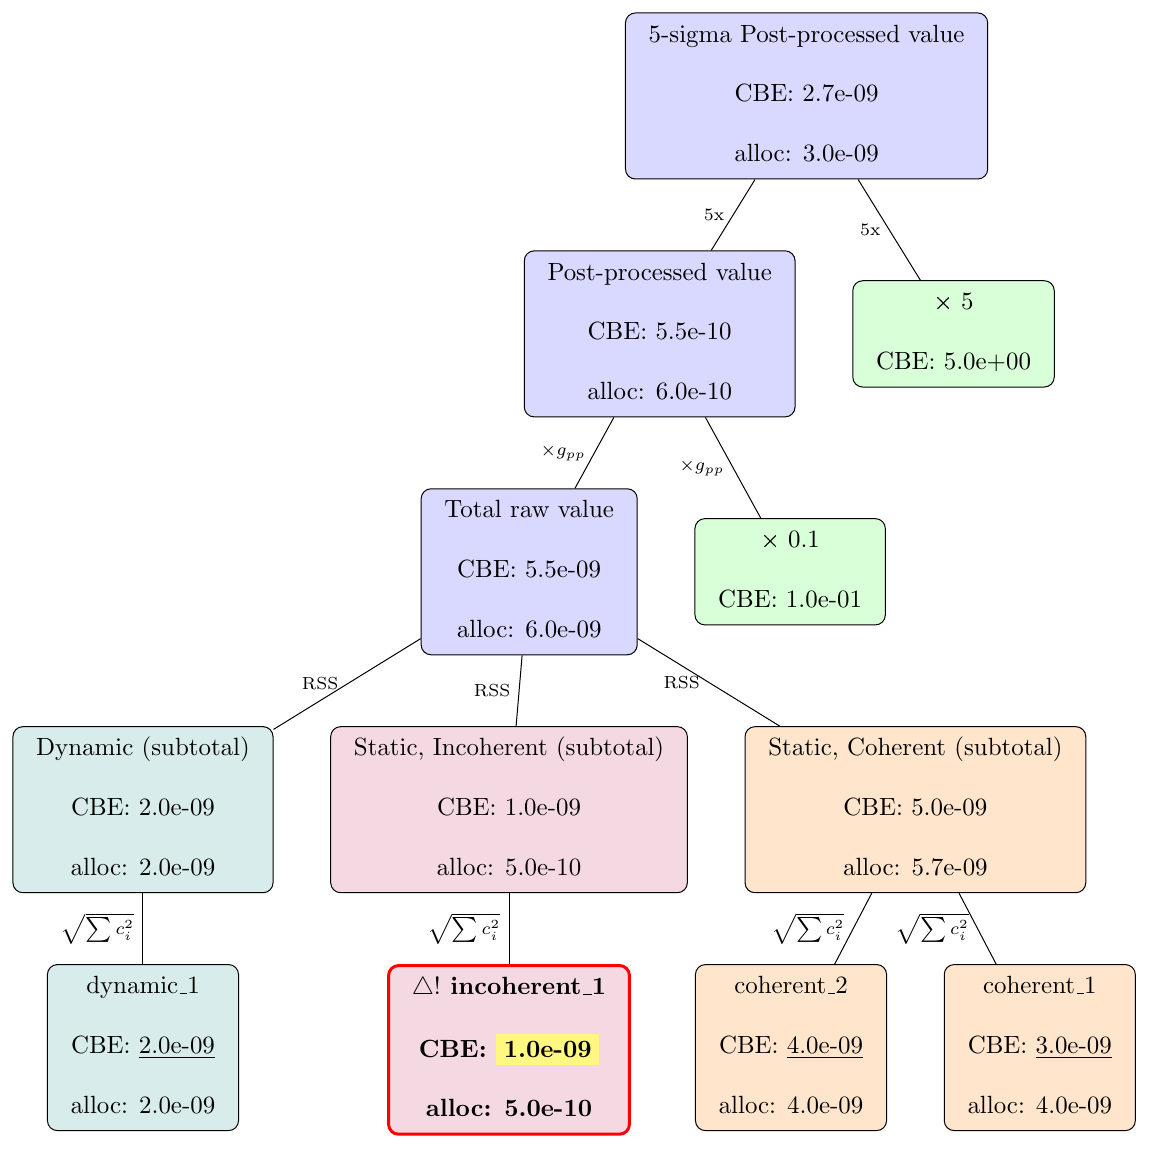

In [5]:
forest_tex = render_tikz(node, show="both", standalone=True, layout="forest")
tree_png(forest_tex)


## `layout="outline"`

A directory-style indented outline. Same colour block and same cues — only the
geometry differs.

**Known limitation:** this layout uses tikz's `grow via three points`, which
places children at *fixed* offsets and cannot account for varying subtree
heights. Nested subtrees with wide labels therefore overlap, as visible below.
For production figures, compute node coordinates explicitly — this is why
`schmidt_ESP_template` lays out its own outline rather than using this one.


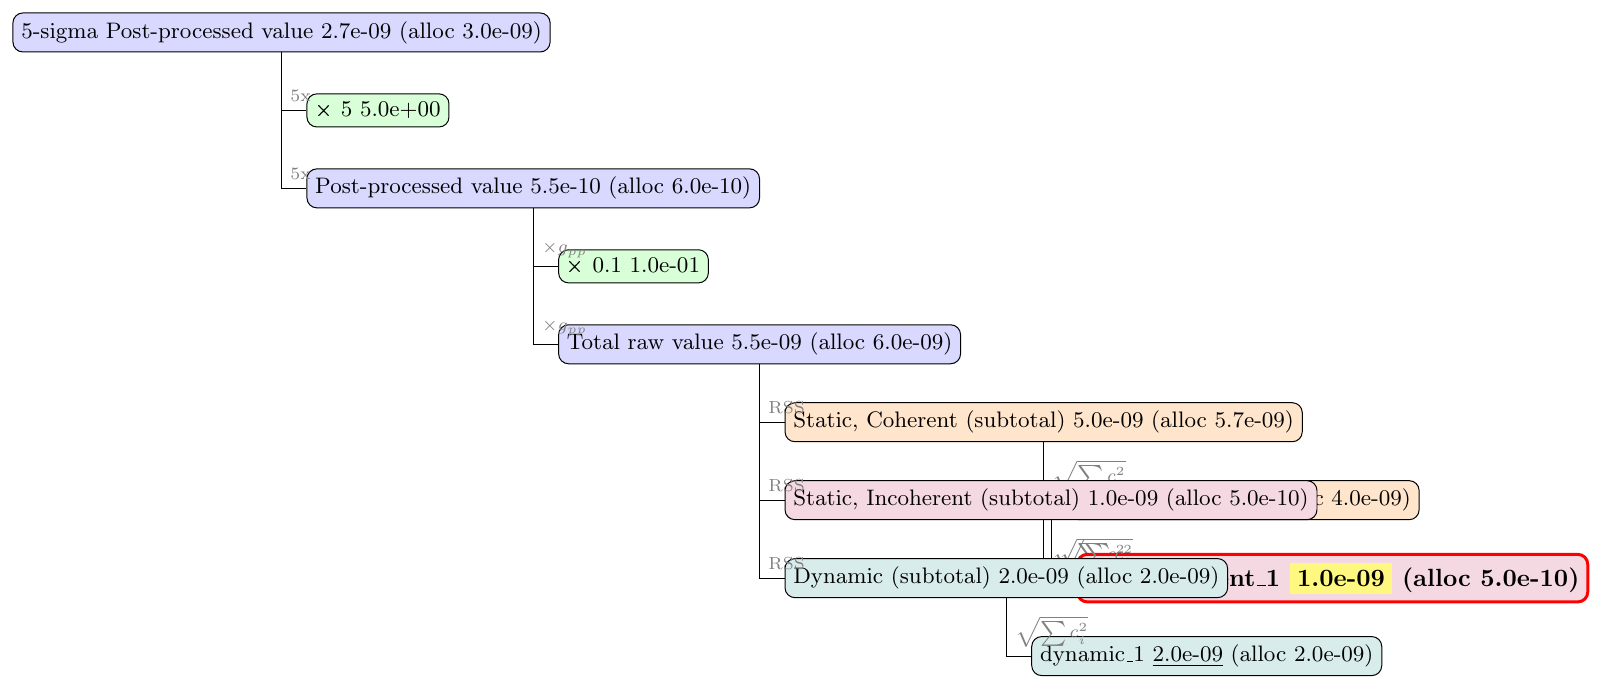

In [6]:
outline_tex = render_tikz(node, show="both", standalone=True, layout="outline")
tree_png(outline_tex)


## `alert_on_exceedances=False`

Suppresses **only** the negative cues (red border, `△!`, yellow highlight); the
`overallocated` style is not even defined. Per-`Type` fills and the
within-allocation underline remain. This is the flag the exposure-time
calculator passes.


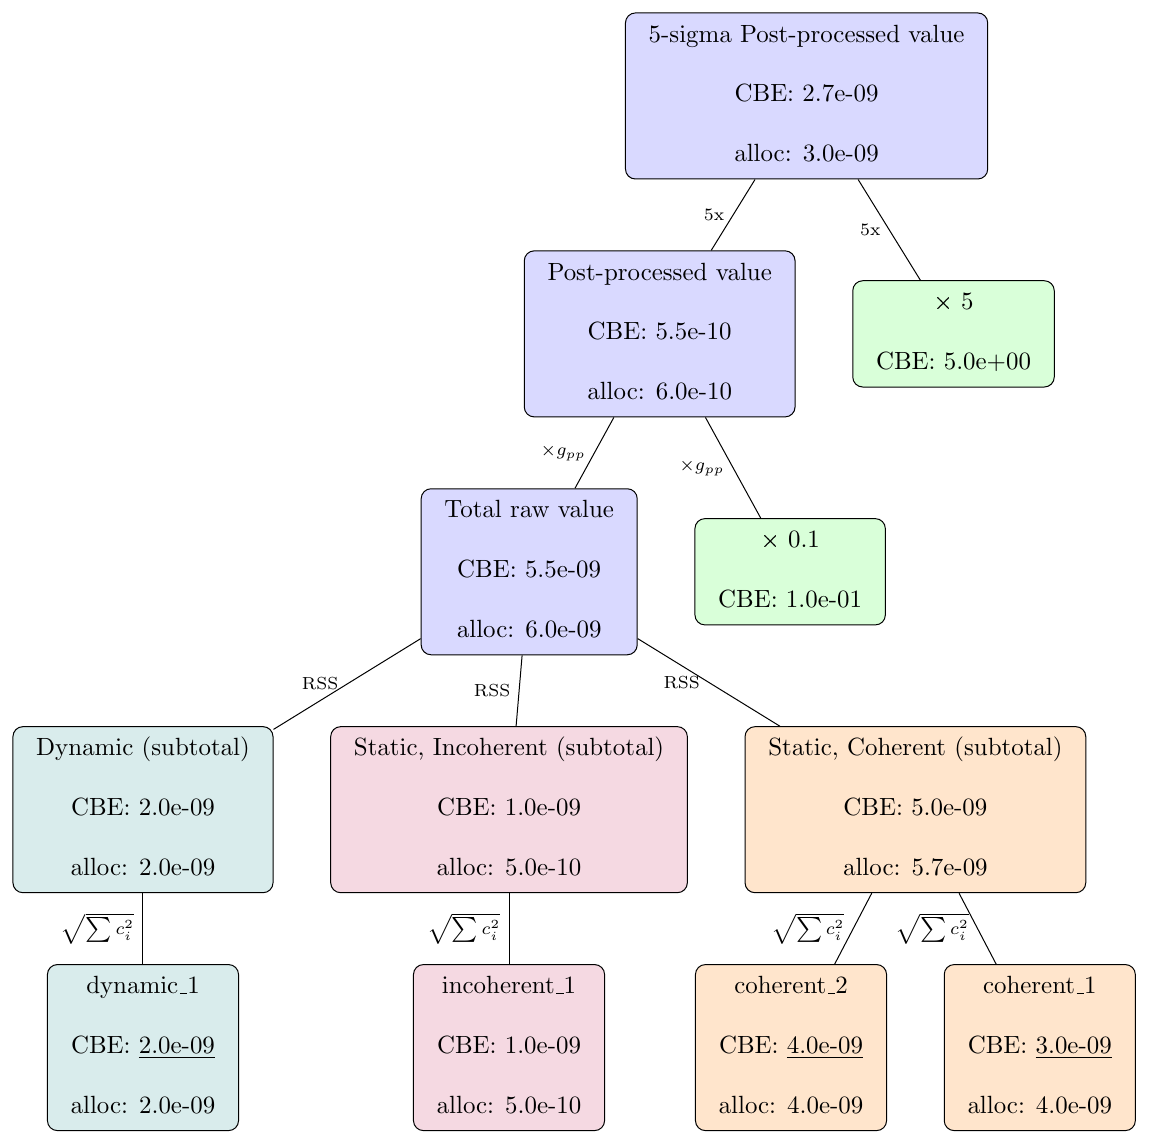

In [7]:
plain_tex = render_tikz(node, show="both", standalone=True, alert_on_exceedances=False)
tree_png(plain_tex)


## Interactive use

In a live session `display_tree` does build + render + compile in one call and
shows the PDF inline:

```python
display_tree(node, show="both", layout="forest")
```

It is not executed here because its `IFrame` output references a temporary path
that would not resolve for anyone else opening this notebook.
